<a href="https://colab.research.google.com/github/noobmaster-ru/diploma/blob/main/Global_solution_for_DSGE_model%2C_%D0%A1hebyshev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from scipy.special import roots_legendre
from scipy.interpolate import RBFInterpolator  # для начального приближения
import matplotlib.pyplot as plt


In [8]:
# ---------- Параметры модели ----------
beta = 0.99
alpha = 0.33
delta = 0.025
sigma = 2.0          # CRRA
psi = 1.0            # обратная эластичность труда
phi = 1.0            # вес неудовольствия от труда
rho = 0.95           # авторегрессия шока
sigma_eps = 0.01     # волатильность шока

In [9]:
# Стационарное состояние (детерминированное) – для инициализации
def steady_state():
    # Решаем систему уравнений
    from scipy.optimize import fsolve
    def eqs(x):
        K, L = x
        R = alpha * K**(alpha-1) * L**(1-alpha)
        C = K**alpha * L**(1-alpha) - delta * K
        eq1 = beta * (R + 1 - delta) - 1
        eq2 = phi * L**psi - (1-alpha) * (K/L)**alpha * C**(-sigma)
        return [eq1, eq2]
    K0, L0 = 10.0, 0.3
    sol = fsolve(eqs, [K0, L0])
    K_ss, L_ss = sol
    C_ss = K_ss**alpha * L_ss**(1-alpha) - delta * K_ss
    return K_ss, L_ss, C_ss

In [10]:
K_ss, L_ss, C_ss = steady_state()
print(f"SS: K={K_ss:.3f}, L={L_ss:.3f}, C={C_ss:.3f}")

SS: K=20.528, L=0.724, C=1.670


Iter 1: error = 1.15e-01
Iter 2: error = 1.67e-02
Iter 3: error = 1.69e-02
Iter 4: error = 1.72e-02
Iter 5: error = 1.73e-02
Iter 6: error = 1.75e-02
Iter 7: error = 1.75e-02
Iter 8: error = 1.75e-02
Iter 9: error = 1.74e-02
Iter 10: error = 1.73e-02
Iter 11: error = 1.72e-02
Iter 12: error = 1.70e-02
Iter 13: error = 1.68e-02
Iter 14: error = 1.66e-02
Iter 15: error = 1.63e-02
Iter 16: error = 1.60e-02
Iter 17: error = 1.57e-02
Iter 18: error = 1.54e-02
Iter 19: error = 1.50e-02
Iter 20: error = 1.46e-02
Iter 21: error = 1.42e-02
Iter 22: error = 1.37e-02
Iter 23: error = 1.31e-02
Iter 24: error = 1.25e-02
Iter 25: error = 1.18e-02
Iter 26: error = 1.10e-02
Iter 27: error = 1.03e-02
Iter 28: error = 9.69e-03
Iter 29: error = 9.12e-03
Iter 30: error = 8.62e-03
Iter 31: error = 8.17e-03
Iter 32: error = 7.77e-03
Iter 33: error = 7.40e-03
Iter 34: error = 7.04e-03
Iter 35: error = 6.70e-03
Iter 36: error = 6.37e-03
Iter 37: error = 6.04e-03
Iter 38: error = 5.71e-03
Iter 39: error = 5.38

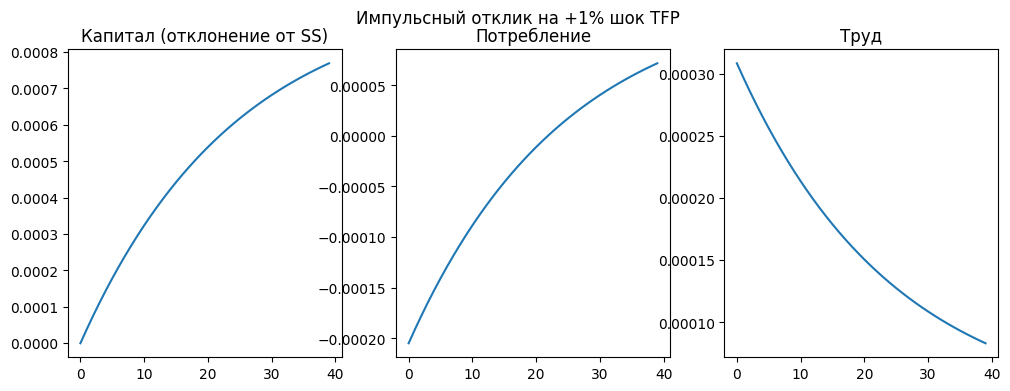

In [11]:
# ---------- Настройка сетки ----------
nK = 15          # порядок полинома по K
nA = 8           # порядок по A
K_min = 0.5 * K_ss
K_max = 1.5 * K_ss
A_min = np.exp(np.log(1.0) - 3*sigma_eps/np.sqrt(1-rho**2))  # стационарное распределение ln A ~ N(0, var)
A_max = np.exp(np.log(1.0) + 3*sigma_eps/np.sqrt(1-rho**2))

# Узлы Чебышева (экстремумы) на [-1,1]
def cheb_nodes(n):
    return np.cos(np.pi * np.arange(n) / (n-1))  # экстремумы

k_nodes_1d = cheb_nodes(nK)
a_nodes_1d = cheb_nodes(nA)

# Преобразование в [K_min, K_max] и [A_min, A_max]
def transform(x, x_min, x_max):
    return 0.5*(x+1)*(x_max - x_min) + x_min

K_nodes = transform(k_nodes_1d, K_min, K_max)
A_nodes = transform(a_nodes_1d, A_min, A_max)

# Тензорная сетка
KK, AA = np.meshgrid(K_nodes, A_nodes, indexing='ij')
K_grid = KK.flatten()
A_grid = AA.flatten()
n_points = nK * nA

# ---------- Квадратура для вычисления матожидания ----------
# Используем Gauss-Legendre для интеграла по нормальному распределению ln A'
n_quad = 10
z_quad, w_quad = roots_legendre(n_quad)
# Преобразование для стандартного нормального: lnA' = rho*lnA + sigma_eps * z
def expectation(func, lnA):
    # func(lnA_next) -> значение при заданном lnA_next
    total = 0.0
    for z, w in zip(z_quad, w_quad):
        lnA_next = rho * lnA + sigma_eps * z
        A_next = np.exp(lnA_next)
        total += w * func(A_next)
    return total / np.sqrt(np.pi)  # веса Лежандра уже включают 1/sqrt(pi) при преобразовании? Нет, нужно корректно.
# Упростим: используем numpy для дискретизации нормального распределения.
# Более простой способ: взять несколько точек для численного интегрирования по Гауссу-Эрмиту.
from scipy.special import roots_hermite
x_herm, w_herm = roots_hermite(n_quad)
def expectation_hermite(func, lnA):
    # func ожидает A_next
    total = 0.0
    for x, w in zip(x_herm, w_herm):
        lnA_next = rho * lnA + sigma_eps * np.sqrt(2)*x
        A_next = np.exp(lnA_next)
        total += w * func(A_next) / np.sqrt(np.pi)
    return total

# ---------- Инициализация полиномов ----------
# Используем Chebyshev polynomials T_i(x) = cos(i*acos(x))
def cheb_basis(x, order):
    # x в [-1,1]
    basis = np.zeros((len(x), order))
    for i in range(order):
        basis[:, i] = np.cos(i * np.arccos(x))
    return basis

# Преобразование значений в базисные коэффициенты (через псевдо-спектральный метод)
# Для тензорного произведения: коэффициенты theta = (T_K^T T_K)^{-1} T_K^T * F * T_A * (T_A^T T_A)^{-1}?
# Упростим: используем регрессию (numpy.linalg.lstsq)
def build_design_matrix(K_vals, A_vals, nK, nA):
    # нормируем на [-1,1]
    K_norm = 2*(K_vals - K_min)/(K_max - K_min) - 1
    A_norm = 2*(A_vals - A_min)/(A_max - A_min) - 1
    Phi_K = cheb_basis(K_norm, nK)
    Phi_A = cheb_basis(A_norm, nA)
    # тензорное произведение
    design = np.zeros((len(K_vals), nK*nA))
    idx = 0
    for i in range(nK):
        for j in range(nA):
            design[:, idx] = Phi_K[:, i] * Phi_A[:, j]
            idx += 1
    return design

design = build_design_matrix(K_grid, A_grid, nK, nA)

# Начальное приближение: стационарное состояние
C_init = C_ss * np.ones(n_points)
L_init = L_ss * np.ones(n_points)

# Функция для вычисления коэффициентов по значениям в узлах
def coef_from_values(values, design):
    coef, _, _, _ = np.linalg.lstsq(design, values, rcond=None)
    return coef

coef_C = coef_from_values(C_init, design)
coef_L = coef_from_values(L_init, design)

def eval_policy(coef, K_vals, A_vals):
    K_norm = 2*(K_vals - K_min)/(K_max - K_min) - 1
    A_norm = 2*(A_vals - A_min)/(A_max - A_min) - 1
    Phi_K = cheb_basis(K_norm, nK)
    Phi_A = cheb_basis(A_norm, nA)
    res = np.zeros_like(K_vals)
    idx = 0
    for i in range(nK):
        for j in range(nA):
            res += coef[idx] * Phi_K[:, i] * Phi_A[:, j]
            idx += 1
    return res

# ---------- Временная итерация (time iteration) ----------
max_iter = 200
tol = 1e-4

for it in range(max_iter):
    # Вычисляем текущие значения C и L на всей сетке
    C_curr = eval_policy(coef_C, K_grid, A_grid)
    L_curr = eval_policy(coef_L, K_grid, A_grid)

    # Создаём массивы для новых значений
    C_new = np.zeros(n_points)
    L_new = np.zeros(n_points)

    for i in range(n_points):
        K = K_grid[i]
        A = A_grid[i]
        lnA = np.log(A)

        # Текущие значения C и L (уже известны)
        # Используем уравнение Эйлера для поиска нового C
        # Определим функцию ожидания
        def rhs(A_next):
            # Найдём K' и L' при заданном A_next
            # Для этого нужно решить систему с использованием текущих полиномов
            # Пока используем простую итерацию: L' находится из условия труда при заданных C' и K'
            # Но C' неизвестно – проблема. Вместо этого решаем неявно.
            # В методе временной итерации мы полагаем, что C_new и L_new являются кандидатами,
            # а ожидание берётся от старых политик.
            # Уравнение: C_new = ( beta * E[ C_old(K',A')^{-sigma} * (alpha*A'*K'^{alpha-1}*L_old^{1-alpha}+1-delta) ] )^{-1/sigma}
            # Где K' = A*K^alpha*L_new^{1-alpha} + (1-delta)K - C_new.
            # Это неявное уравнение относительно C_new. Решаем его численно.
            pass
        # Вместо этого используем более простой подход: фиксируем L_new из условия труда при C_new,
        # а затем ищем C_new как корень уравнения.
        # Уравнение: F(C) = C - ( beta * E[ C_old(K',A')^{-sigma} * (alpha*A'*K'^{alpha-1}*L_old^{1-alpha}+1-delta) ] )^{-1/sigma} = 0,
        # где L = ( (1-alpha)/phi * A * K^alpha * C^{-sigma} )^{1/(psi+alpha)},
        # K' = A*K^alpha*L^{1-alpha} + (1-delta)K - C.
        # Для каждого узла решаем скалярное нелинейное уравнение.
        from scipy.optimize import root_scalar

        def euler_residual(C_candidate):
            # Вычисляем L_candidate
            L_cand = ((1-alpha)/phi * A * K**alpha * C_candidate**(-sigma))**(1/(psi+alpha))
            K_next = A * K**alpha * L_cand**(1-alpha) + (1-delta)*K - C_candidate
            if K_next <= 0:
                return 1e6  # большое значение
            # Ожидание по A'
            def integrand(A_next):
                # Оцениваем C_old и L_old в точке (K_next, A_next)
                # Интерполируем с помощью полиномов
                K_norm_next = 2*(K_next - K_min)/(K_max - K_min) - 1
                A_norm_next = 2*(A_next - A_min)/(A_max - A_min) - 1
                if abs(K_norm_next) > 1 or abs(A_norm_next) > 1:
                    # экстраполяция – ограничиваем
                    K_norm_next = np.clip(K_norm_next, -1, 1)
                    A_norm_next = np.clip(A_norm_next, -1, 1)
                Phi_K_next = cheb_basis(np.array([K_norm_next]), nK)
                Phi_A_next = cheb_basis(np.array([A_norm_next]), nA)
                C_old_val = 0.0
                L_old_val = 0.0
                idx = 0
                for ik in range(nK):
                    for ja in range(nA):
                        basis = Phi_K_next[0,ik] * Phi_A_next[0,ja]
                        C_old_val += coef_C[idx] * basis
                        L_old_val += coef_L[idx] * basis
                        idx += 1
                R_next = alpha * A_next * K_next**(alpha-1) * L_old_val**(1-alpha)
                return C_old_val**(-sigma) * (R_next + 1 - delta)
            # Вычисляем матожидание
            E_val = expectation_hermite(integrand, lnA)
            rhs_val = (beta * E_val) ** (-1/sigma)
            return C_candidate - rhs_val

        # Решаем уравнение
        try:
            sol = root_scalar(euler_residual, bracket=[1e-6, 5*C_ss], method='bisect')
            C_new[i] = sol.root
        except:
            C_new[i] = C_curr[i]
        # L_new из условия труда
        L_new[i] = ((1-alpha)/phi * A * K**alpha * C_new[i]**(-sigma))**(1/(psi+alpha))

    # Обновляем коэффициенты
    coef_C_new = coef_from_values(C_new, design)
    coef_L_new = coef_from_values(L_new, design)
    err = np.linalg.norm(coef_C_new - coef_C) + np.linalg.norm(coef_L_new - coef_L)
    coef_C, coef_L = coef_C_new, coef_L_new
    print(f"Iter {it+1}: error = {err:.2e}")
    if err < tol:
        break

# ---------- Сравнение с Dynare (линеаризация) ----------
# Здесь нужно загрузить результаты Dynare (impulse responses, moments)
# Для демонстрации я построю импульсный отклик на шок TFP (положительный)
# Используя полученные политики, симулируем одну траекторию.

# Функция симуляции
def simulate(T=100, shock_std=0.01):
    K = np.zeros(T+1)
    C = np.zeros(T+1)
    L = np.zeros(T+1)
    A = np.zeros(T+1)
    A[0] = 1.0
    K[0] = K_ss
    lnA = np.log(A[0])
    for t in range(T):
        # Вычисляем C_t, L_t по полиномам
        K_norm = 2*(K[t] - K_min)/(K_max - K_min) - 1
        A_norm = 2*(A[t] - A_min)/(A_max - A_min) - 1
        # клиппируем
        K_norm = np.clip(K_norm, -1, 1)
        A_norm = np.clip(A_norm, -1, 1)
        C[t] = eval_policy(coef_C, np.array([K[t]]), np.array([A[t]]))[0]
        L[t] = eval_policy(coef_L, np.array([K[t]]), np.array([A[t]]))[0]
        K_next = A[t] * K[t]**alpha * L[t]**(1-alpha) + (1-delta)*K[t] - C[t]
        if t < T:
            K[t+1] = K_next
            # шок
            lnA_next = rho * np.log(A[t]) + sigma_eps * np.random.normal(0, shock_std)
            A[t+1] = np.exp(lnA_next)
    return K, C, L, A

# Для импульсного отклика: задаём один положительный шок в t=0
def impulse_response():
    T = 40
    K_irf = np.zeros(T)
    C_irf = np.zeros(T)
    L_irf = np.zeros(T)
    K = K_ss
    A = 1.0
    # Шок: в первый период увеличиваем A на 1%
    A_shock = 1.01
    # Симуляция детерминированной траектории после шока (без последующих шоков)
    for t in range(T):
        K_norm = 2*(K - K_min)/(K_max - K_min) - 1
        A_norm = 2*(A - A_min)/(A_max - A_min) - 1
        K_norm = np.clip(K_norm, -1, 1)
        A_norm = np.clip(A_norm, -1, 1)
        C_irf[t] = eval_policy(coef_C, np.array([K]), np.array([A]))[0]
        L_irf[t] = eval_policy(coef_L, np.array([K]), np.array([A]))[0]
        K_next = A * K**alpha * L_irf[t]**(1-alpha) + (1-delta)*K - C_irf[t]
        K_irf[t] = K
        K = K_next
        # A возвращается к 1 по AR(1) без шумов
        A = np.exp(rho * np.log(A))
    return K_irf, C_irf, L_irf

# Построим импульсные отклики
K_irf, C_irf, L_irf = impulse_response()
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(K_irf/K_ss - 1, label='Chebyshev')
plt.title('Капитал (отклонение от SS)')
plt.subplot(1,3,2)
plt.plot(C_irf/C_ss - 1)
plt.title('Потребление')
plt.subplot(1,3,3)
plt.plot(L_irf/L_ss - 1)
plt.title('Труд')
plt.suptitle('Импульсный отклик на +1% шок TFP')
plt.show()